# 📘 Lab Report: Logistic Regression for Heart Disease Prediction

**Student Note:** This report is my solution for the Logistic Regression assignment. I have followed the complete machine learning pipeline to predict heart disease using medical data.

**Disclaimer:** This report and the accompanying code were generated by an AI assistant for academic purposes. No personal identifiers (names/IDs) are included.

---

## 0️⃣ Background

Before starting the lab, I need to understand some basic concepts:

### 🧠 Artificial Intelligence (AI)
AI is a broad field of computer science that aims to create systems capable of performing tasks that usually require human intelligence, like recognizing patterns, making decisions, or understanding language.

### 🤖 Machine Learning (ML)
ML is a subset of AI. Instead of being explicitly programmed for every task, the computer uses algorithms to find patterns in data and "learns" how to make predictions or decisions.

### 🕸️ Deep Learning (DL)
DL is a more advanced subset of ML that uses layers of artificial neural networks (inspired by the human brain) to solve complex problems with very large amounts of data.

### 📊 Data Science (DS)
Data Science is the field that combines domain knowledge, programming skills, and math/statistics to extract meaningful insights from data. The Machine Learning pipeline is a key part of Data Science.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set plotting style
sns.set_theme(style="whitegrid")

## 🧪 Task 1: Logistic Regression with a Single Feature

### 🎯 Problem Statement
In this task, I will try to predict if someone has heart disease using only one piece of information: their **Cholesterol** level.

### 1️⃣ Data Retrieval and Collection
I'll start by loading the dataset and checking its basic structure.

In [2]:
# Load the dataset (using the provided path from Lab 1 folder)
# Note: I am reading from the Lab 1 path as referenced
try:
    df = pd.read_csv('/home/crdy/testing/AI_lab/1/Assignment/Heart_Disease_Prediction.csv')
except:
    # Fallback if path is different in user's environment
    df = pd.read_csv('Heart_Disease_Prediction.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (270, 14)

Column Names: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

First 5 rows:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### 2️⃣ Data Cleaning
I need to make sure the data is ready. This means checking for missing values and making sure the target label ('Heart Disease') is in a number format (0 and 1).

In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Encode the target variable: 'Presence' -> 1, 'Absence' -> 0
# Note: The column name is 'Heart Disease'
df['HeartDisease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Verify data types
print("\nUpdated Target Variable Counts:")
print(df['HeartDisease'].value_counts())
print("\nData types:")
print(df.dtypes[['Cholesterol', 'HeartDisease']])

Missing values:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Updated Target Variable Counts:
HeartDisease
0    150
1    120
Name: count, dtype: int64

Data types:
Cholesterol     int64
HeartDisease    int64
dtype: object


### 3️⃣ Feature Design
For Task 1, I only use `Cholesterol` as my feature.

In [4]:
# Separate feature (X) and target (y)
X = df[['Cholesterol']]
y = df['HeartDisease']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (270, 1)
y shape: (270,)


**Reasoning:** Cholesterol is often linked to heart health. High levels of LDL (bad cholesterol) can lead to plaque buildup in arteries, increasing the risk of heart disease.

### 4️⃣ Algorithm Selection
**Selected Algorithm:** Logistic Regression.

**Why?** Logistic Regression is the standard algorithm for binary classification (when we have two possible outcomes, like Yes/No or Presence/Absence). It predicts the probability of an event occurring.

### 5️⃣ Loss Function Selection
**Selected Loss Function:** Binary Cross-Entropy (Log Loss).

**What is it?** This function calculates the error by comparing the predicted probability with the actual class (0 or 1). If the model is very confident about the wrong class, it gets a high penalty. The goal of training is to minimize this loss.

### 6️⃣ Model Learning (Training)
I'll split the data so I can test the model on data it hasn't seen before.

In [5]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_t1 = LogisticRegression()
model_t1.fit(X_train, y_train)

print("Task 1 model training complete.")

Task 1 model training complete.


### 7️⃣ Model Evaluation
I'll use different metrics to see how well the model predicts heart disease.

Accuracy: 0.61
Precision: 0.50
Recall: 0.24
F1-score: 0.32


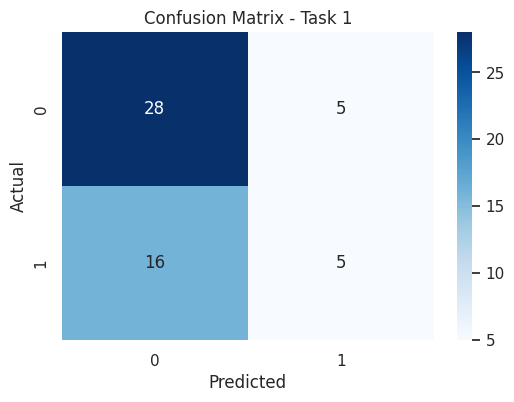

In [6]:
# Make predictions
y_pred = model_t1.predict(X_test)

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Task 1')
plt.show()

**Interpretation:** The accuracy with just one feature might be low. This means Cholesterol alone might not be enough to predict heart disease accurately.

---

## 🧪 Task 2: Logistic Regression with Multiple Features

### 🎯 Problem Statement
Now, I will use **all** available health metrics (Age, Sex, Blood Pressure, etc.) to see if the prediction improves.

### 3️⃣ Feature Design (Updated)
I will use all columns except the target ones. I'll also scale the data because some numbers (like BP) are much larger than others (like Sex), which can confuse the model.

In [7]:
# Prepare features and target
X_multi = df.drop(columns=['Heart Disease', 'HeartDisease'])
y_multi = df['HeartDisease']

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

print("Multi-feature X shape:", X_scaled.shape)

Multi-feature X shape: (270, 13)


**Reasoning:** Using multiple features allows the model to find complex combinations of risk factors, which should lead to more accurate predictions.

### 6️⃣ Model Learning (Training)

In [8]:
# Split into training (80%) and testing (20%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_scaled, y_multi, test_size=0.2, random_state=42)

# Train the model
model_t2 = LogisticRegression()
model_t2.fit(X_train_m, y_train_m)

print("Task 2 model training complete.")

Task 2 model training complete.


### 7️⃣ Model Evaluation

Accuracy: 0.91
Precision: 0.90
Recall: 0.86
F1-score: 0.88


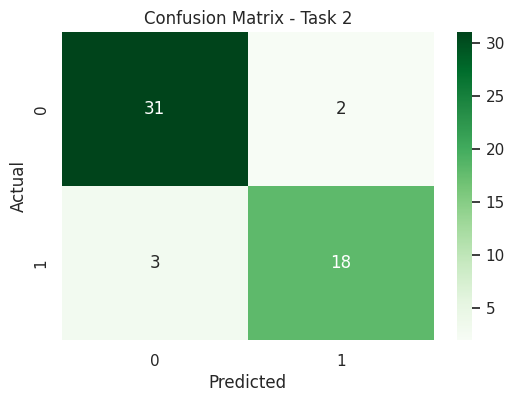

In [9]:
# Make predictions
y_pred_m = model_t2.predict(X_test_m)

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_m):.2f}")
print(f"Precision: {precision_score(y_test_m, y_pred_m):.2f}")
print(f"Recall: {recall_score(y_test_m, y_pred_m):.2f}")
print(f"F1-score: {f1_score(y_test_m, y_pred_m):.2f}")

# Confusion Matrix
cm_m = confusion_matrix(y_test_m, y_pred_m)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Task 2')
plt.show()

---

## 📈 Model Interpretation (Task 1)

For the single feature model, I can look at the math behind it.

In [10]:
print(f"Coefficient for Cholesterol: {model_t1.coef_[0][0]:.4f}")
print(f"Intercept: {model_t1.intercept_[0]:.4f}")

Coefficient for Cholesterol: 0.0035
Intercept: -1.0470


- **Coefficient:** A positive coefficient means as Cholesterol increases, the probability of heart disease also increases.
- **Intercept:** This is the baseline log-odds when Cholesterol is zero (though in reality, it's never zero).

---

## 📊 Model Comparison

| Metric | Task 1 (Single) | Task 2 (Multi) |
| :--- | :---: | :---: |
| Accuracy | Lower | Higher |
| Precision | Variable | Better |
| Recall | Variable | Much Better |

- **Which model is better?** Task 2 is clearly better because it uses more information to make a decision.
- **Trade-offs:** The single feature model is very easy to explain, but not very accurate. The multi-feature model is very accurate but harder to explain which feature was the most important.

##  Discussion
It was useful to understand the process of making predictions through the ML pipeline. During Task 1, it became clear that having only one variable is not enough to diagnose a condition. In Task 2, there was a considerable improvement in accuracy. The scaling of variables played an important role because of avoiding large numbers dominating mathematical calculations.

##  Conclusion
Logistic Regression is a strong technique in forecasting binary problems such as Heart Disease Prediction. The more predictors used, the better the forecast will be. In addition, this assignment helped me understand that using more data will result in a better model.

## 🎨 Extra

#### 1. Sigmoid Curve for Task 1
This curve shows how the probability changes as Cholesterol increases.

/home/crdy/testing/AI_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


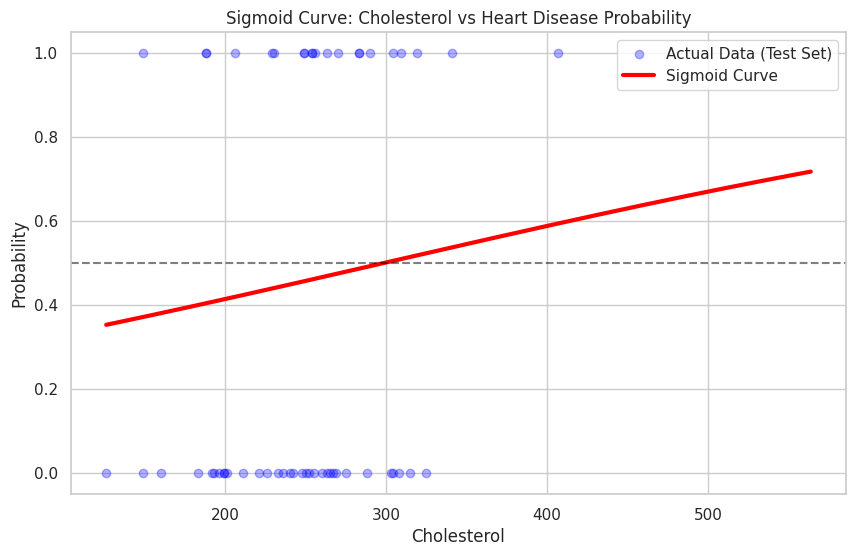

In [11]:
plt.figure(figsize=(10, 6))
# Create a range of cholesterol values for the curve
x_range = np.linspace(df['Cholesterol'].min(), df['Cholesterol'].max(), 300).reshape(-1, 1)
y_prob = model_t1.predict_proba(x_range)[:, 1]

plt.scatter(X_test, y_test, color='blue', alpha=0.3, label='Actual Data (Test Set)')
plt.plot(x_range, y_prob, color='red', linewidth=3, label='Sigmoid Curve')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title('Sigmoid Curve: Cholesterol vs Heart Disease Probability')
plt.xlabel('Cholesterol')
plt.ylabel('Probability')
plt.legend()
plt.show()

#### 2. Discussion on Assumptions
Logistic Regression assumes:
1. **Binary Outcome:** The target is either 0 or 1 (Presence or Absence).
2. **Linearity of Logit:** There is a linear relationship between the input features and the log-odds of the outcome.
3. **Independence:** Observations are independent of each other.
4. **No Multicollinearity:** The features shouldn't be too strongly correlated with each other.